In [30]:
# Librerias
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image

import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

#  Comparación de Modelos en Dataset Externo (ISIC)

En este archivo vamos a comparar el **rendimiento de tres modelos preseleccionados**:

- `MelanomaNet.h5`
- `simpleNet.h5`

Estos modelos fueron previamente entrenados en nuestro dataset interno, pero el objetivo de este análisis es evaluar **su capacidad de generalización** frente a imágenes nuevas y no vistas.



**Objetivo del análisis**

- Evaluar cómo responden los modelos al ser expuestos a imágenes externas provenientes de una fuente diferente.  
- Analizar métricas de rendimiento (precisión, recall, matriz de confusión, etc.) en este nuevo contexto.  
- Identificar cuál modelo es más robusto y consistente al enfrentarse a **datos fuera de la distribución original**.


**Dataset Externo: ISIC***

El dataset externo utilizado corresponde al **International Skin Imaging Collaboration (ISIC)**, una de las mayores bases de datos públicas de imágenes dermatológicas.  
Este conjunto incluye imágenes de lesiones cutáneas benignas y malignas, con gran diversidad en condiciones de iluminación, dispositivos y pacientes.

🔗 [Acceso al dataset ISIC](https://www.isic-archive.com/)





## Carga Modelos

In [20]:
# Rutas de los modelos
path_melanoma = "../models/MelanomaNet.h5"
path_simple = "../models/simpleNet.h5"

In [23]:
melanoma_model = keras.models.load_model(path_melanoma)
simple_model  = keras.models.load_model(path_simple)

In [24]:
print(" Resumen de MelanomaNet")
melanoma_model.summary()

print("\n Resumen de SimpleNet")
simple_model.summary()

 Resumen de MelanomaNet
Model: "MelanomaNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2 (Conv2D)              (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (

## Comparación Modelos

In [25]:
external_dir = "../data/lesions/external"
ROWS, COLS = 224, 224
labels = ["Benign", "Malignant"] 

In [27]:
# Crear dataset de rutas e índices
def preprocess_img(img_path):
    img = image.load_img(img_path, target_size=(ROWS, COLS))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch dimension
    return img_array


In [28]:
# Crear listas de rutas e índices verdaderosº
img_paths, true_classes = [], []
for label_idx, label in enumerate(labels):
    folder = os.path.join(external_dir, label)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.jpg','.jpeg','.png')):
            img_paths.append(os.path.join(folder, fname))
            true_classes.append(label_idx)

true_classes = np.array(true_classes)

In [33]:
# Función para evaluar modelos
def evaluar_modelo_manual(model, model_name, img_paths, true_classes, labels, N=45):
    print(f"\n Evaluación del modelo: {model_name}")

    pred_classes, pred_probs = [], []

    for path in img_paths:
        img_array = preprocess_img(path)
        probs = model.predict(img_array, verbose=0)
        pred_classes.append(np.argmax(probs))
        pred_probs.append(probs[0])

    pred_classes = np.array(pred_classes)
    pred_probs = np.array(pred_probs)

    # --- Reporte ---
    print(classification_report(true_classes, pred_classes, target_names=labels))

    # --- Matriz de confusión ---
    cm = confusion_matrix(true_classes, pred_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusión - {model_name}")
    plt.show()

    # --- Visualización ---
    rows, cols = 5, 10
    N = min(N, len(img_paths))
    plt.figure(figsize=(18, 12))
    for i in range(N):
        img = image.load_img(img_paths[i], target_size=(ROWS, COLS))
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)

        true_label = labels[true_classes[i]]
        pred_label = labels[pred_classes[i]]
        prob = pred_probs[i][pred_classes[i]]

        color = "green" if true_label == pred_label else "red"
        plt.title(f"{i+1}\nPred: {pred_label}\nTrue: {true_label}\n({prob:.2f})", 
                  color=color, fontsize=9)
        plt.axis('off')

    plt.tight_layout(pad=1.5)
    plt.suptitle(f"Predicciones de {model_name} en imágenes externas", fontsize=16, y=1.03)
    plt.show()


## Evaluación Modelos


 Evaluación del modelo: MelanomaNet
              precision    recall  f1-score   support

      Benign       0.72      0.82      0.77        22
   Malignant       0.80      0.70      0.74        23

    accuracy                           0.76        45
   macro avg       0.76      0.76      0.76        45
weighted avg       0.76      0.76      0.75        45



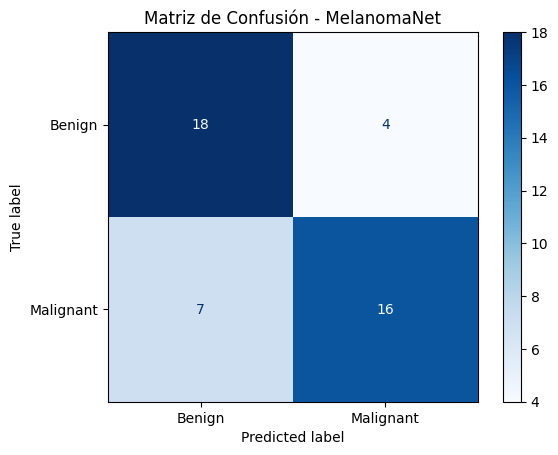

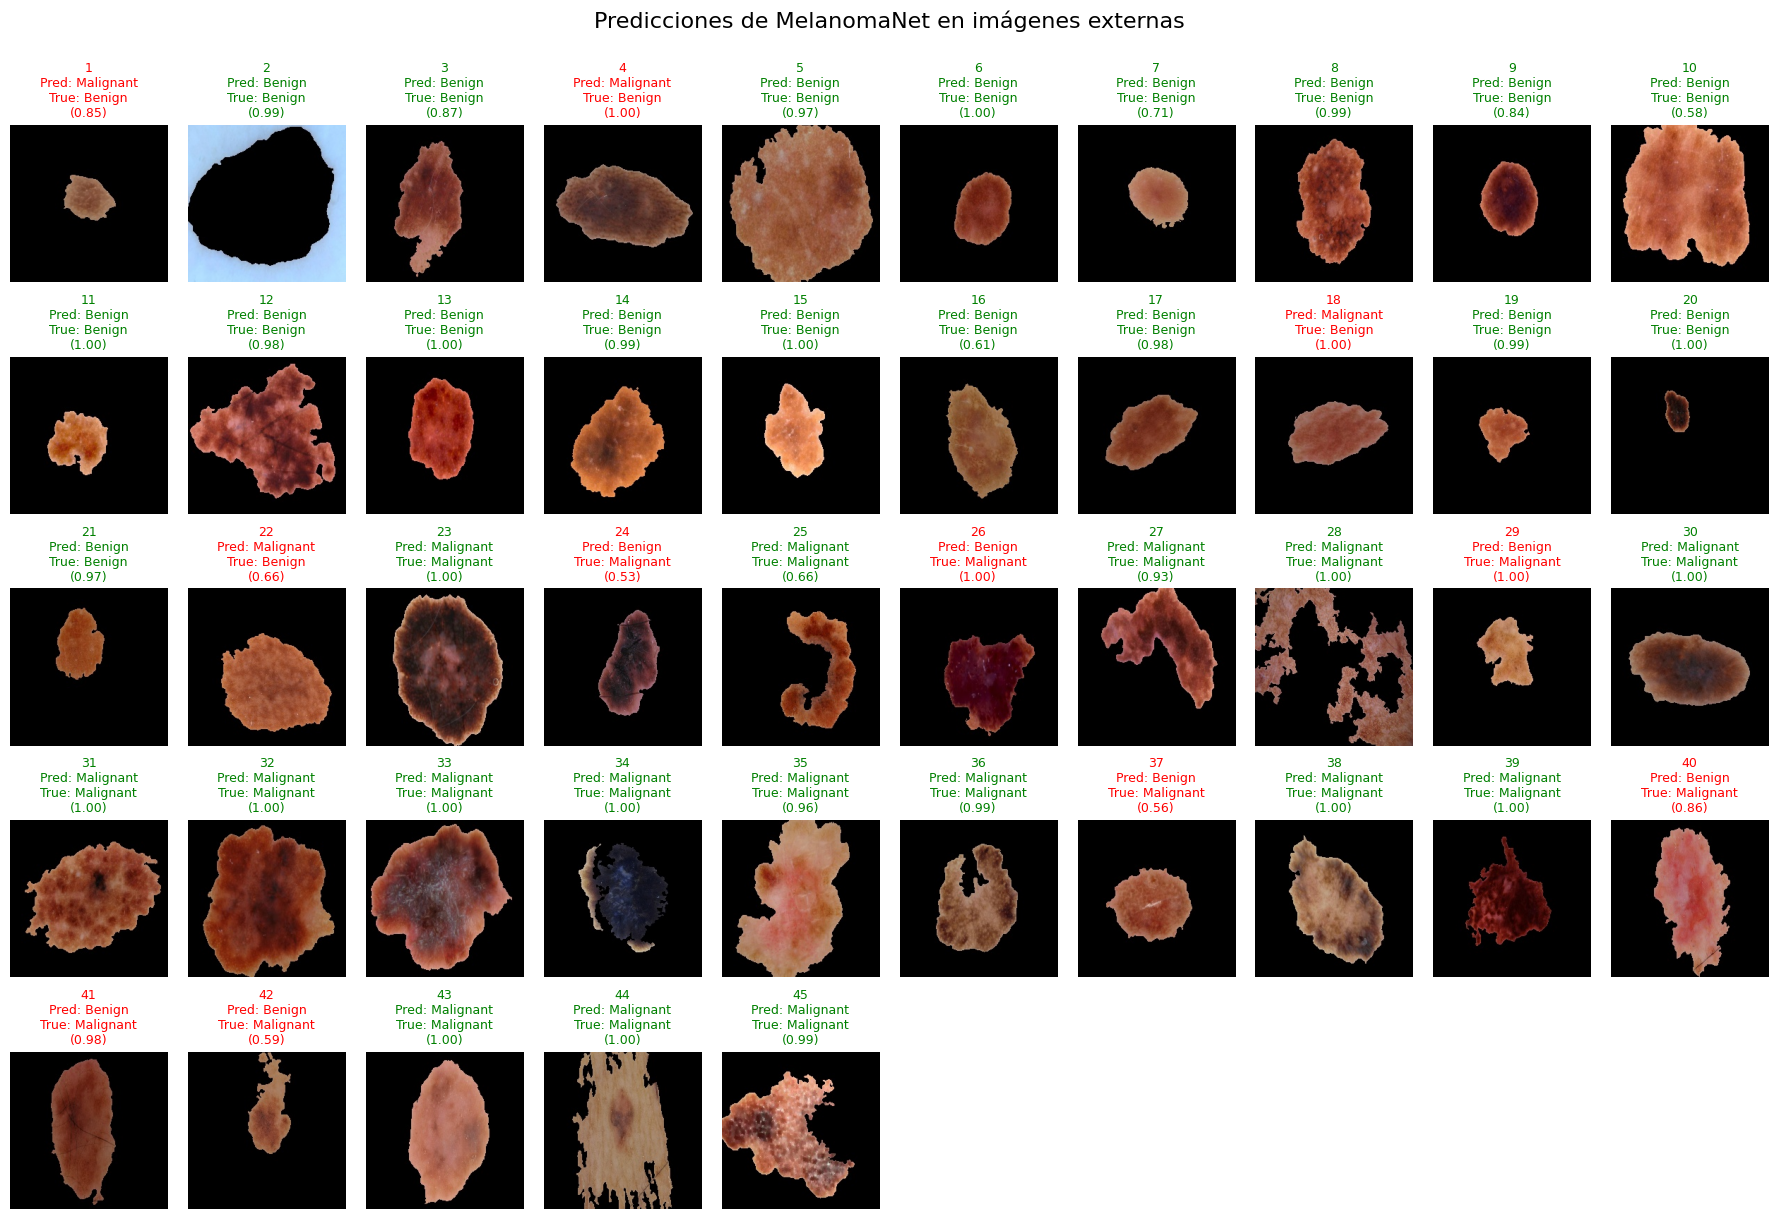


 Evaluación del modelo: SimpleNet
              precision    recall  f1-score   support

      Benign       0.76      0.59      0.67        22
   Malignant       0.68      0.83      0.75        23

    accuracy                           0.71        45
   macro avg       0.72      0.71      0.71        45
weighted avg       0.72      0.71      0.71        45



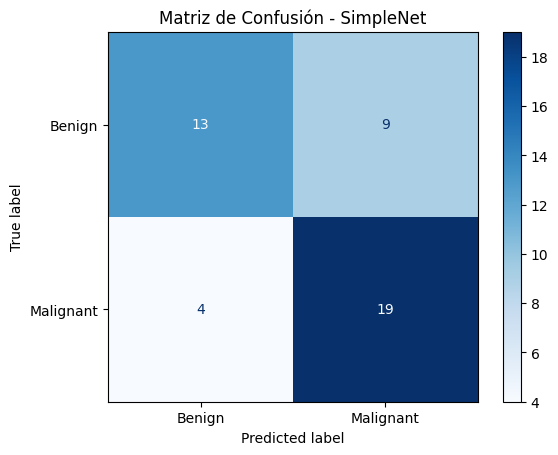

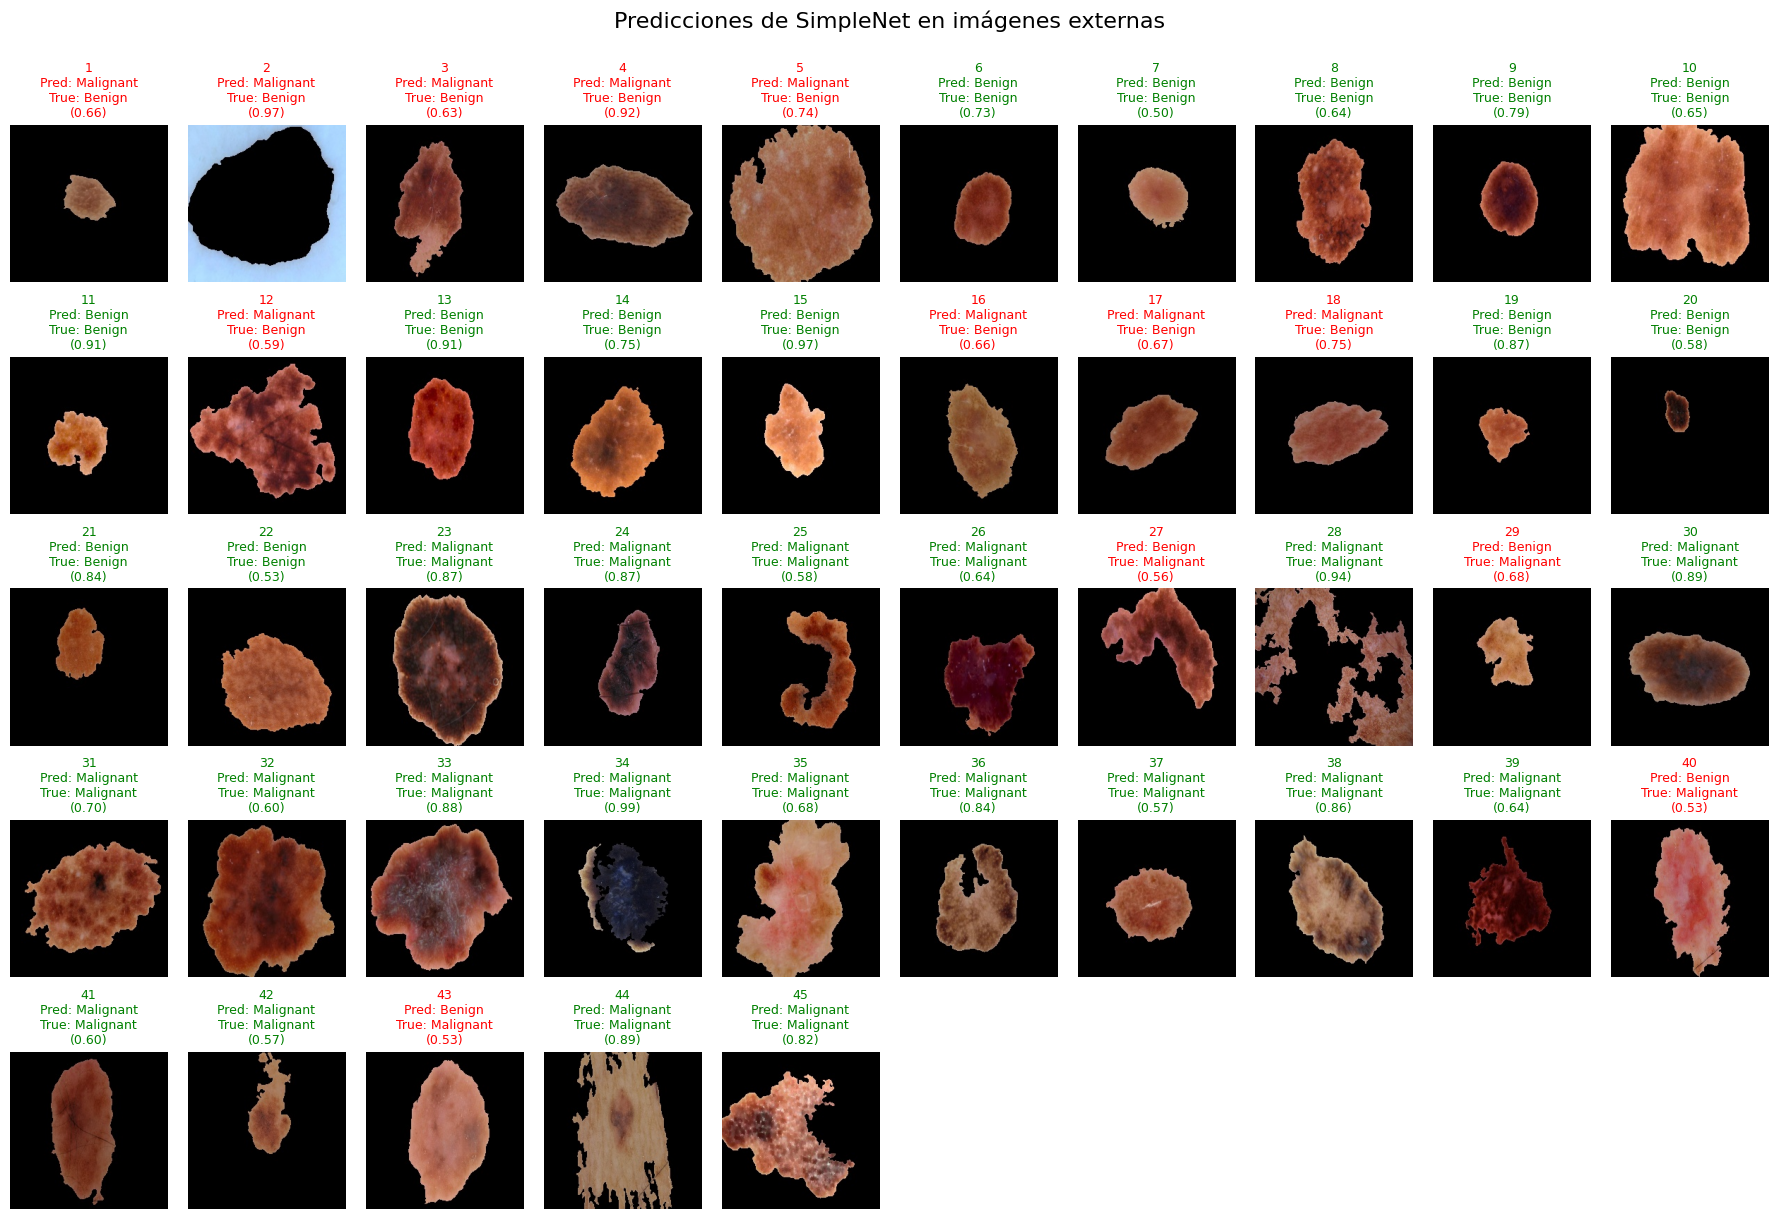

In [34]:
evaluar_modelo_manual(melanoma_model, "MelanomaNet", img_paths, true_classes, labels)
evaluar_modelo_manual(simple_model, "SimpleNet", img_paths, true_classes, labels)

# Conclusiones Comparativas de Modelos

Tras evaluar el rendimiento de los dos modelos entrenados (**MelanomaNet** y **SimpleNet**) sobre un conjunto externo de imágenes se obtienen las siguientes observaciones:


1. **Análisis de Curvas de Entrenamiento**
- **MelanomaNet**: muestra un claro **sobreajuste**.  
  Las curvas de entrenamiento siguen mejorando mientras que las de validación son más irregulares y con peor rendimiento.  

- **SimpleNet**: presenta curvas más **estables y paralelas** entre entrenamiento y validación, indicando **mejor capacidad de generalización**.  


2. **Análisis en Conjunto Externo**
- **MelanomaNet**:  
  - Mayor cantidad de **falsos negativos** (melanomas predichos como benignos).  
  - Esto representa un **riesgo clínico relevante**, ya que un melanoma no detectado es más grave que un falso positivo.  

- **SimpleNet**:  
  - Menor número de falsos negativos → **detecta mejor los melanomas**.  
  - Aunque comete más falsos positivos (benignos detectados como malignos), en el contexto médico esto es **menos peligroso**, ya que el paciente recibiría seguimiento adicional.  




3. **Balance Bias-Varianza**
- **MelanomaNet**: modelo más complejo, con **alta varianza**.  
  Sobreaprende el conjunto de entrenamiento y pierde robustez en datos externos.  

- **SimpleNet**: modelo más ligero, con **menor varianza**, generaliza mejor y se adapta mejor a fuentes externas de datos.  




 **Modelo seleccionado para despliegue: `SimpleNet`**  

- Mayor estabilidad en entrenamiento y validación.  
- Mejor desempeño en la detección de casos malignos (**prioridad clínica**).  
- Más ligero y rápido, lo que facilita su despliegue en plataformas como **Hugging Face**.  